In [20]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sartajbhuvaji
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/no_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/pituitary_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/meningioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/glioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/no_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/pituitary_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/meningioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Test

In [22]:
import os
import numpy as np
import pandas as pd
import pathlib
import imageio
from glob import glob

In [23]:
from glob import glob

base_dir = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri"

glioma = glob(base_dir + "/Training/glioma_tumor/*")
meningioma = glob(base_dir + "/Training/meningioma_tumor/*")
no_tumor = glob(base_dir + "/Training/no_tumor/*")
pituitary = glob(base_dir + "/Training/pituitary_tumor/*")

print("Glioma Images:", len(glioma))
print("Meningioma Images:", len(meningioma))
print("No Tumor Images:", len(no_tumor))
print("Pituitary Images:", len(pituitary))
print("\nTotal Images:",len(glioma + meningioma + no_tumor + pituitary))

Glioma Images: 826
Meningioma Images: 822
No Tumor Images: 395
Pituitary Images: 827

Total Images: 2870


In [24]:
import random

# Glioma
glioma_train = glioma[:660]
glioma_test  = glioma[660:784]
glioma_val   = glioma[784:826]

# Meningioma
meningioma_train = meningioma[:657]
meningioma_test  = meningioma[657:781]
meningioma_val   = meningioma[781:822]

# No Tumor
no_train = no_tumor[:316]
no_test  = no_tumor[316:375]
no_val   = no_tumor[375:395]

# Pituitary
pituitary_train = pituitary[:661]
pituitary_test  = pituitary[661:785]
pituitary_val   = pituitary[785:827]

train_imgs = ( glioma_train + meningioma_train + no_train + pituitary_train)
test_imgs = ( glioma_test + meningioma_test +no_test + pituitary_test)
val_imgs = (glioma_val +meningioma_val +no_val +pituitary_val)

print("Total Train Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % (len(train_imgs),len(glioma_train),len(meningioma_train),len(no_train),len(pituitary_train)))

print("Total Test Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % ( len(test_imgs), len(glioma_test), len(meningioma_test), len(no_test), len(pituitary_test)))

print("Total Validation Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % (len(val_imgs),len(glioma_val),len(meningioma_val),len(no_val),len(pituitary_val)))

random.seed(42)
random.shuffle(glioma)
random.shuffle(meningioma)
random.shuffle(no_tumor)
random.shuffle(pituitary)

Total Train Images 2294 containing 660 glioma, 657 meningioma, 316 no_tumor and 661 pituitary images
Total Test Images 431 containing 124 glioma, 124 meningioma, 59 no_tumor and 124 pituitary images
Total Validation Images 145 containing 42 glioma, 41 meningioma, 20 no_tumor and 42 pituitary images


In [25]:
import cv2
img_size = 224

def preprocess_image(image_list):
    
    X = [] # images
    y = [] #labels (0 for Normal or 1 for Pneumonia)
    count=0
    
    for image in image_list:
        try:
            img = cv2.imread(image,cv2.IMREAD_GRAYSCALE)
            img=cv2.resize(img,(img_size,img_size),interpolation=cv2.INTER_CUBIC)

            #convert image to 2D to 3D 
            img = np.dstack([img, img, img])
            #convrt greyscale image to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Normalalize Image
            img = img.astype(np.float32)/255.
            count=count+1
            X.append(img) 
        except:
            continue
        #get the labels 
        # get the labels

        if 'glioma_tumor' in image:
            y.append(0)

        elif 'meningioma_tumor' in image:
            y.append(1)

        elif 'no_tumor' in image:
            y.append(2)
        
        elif 'pituitary_tumor' in image:
            y.append(3)
            
    return np.array(X), np.array(y)

In [26]:
X_train, y_train = preprocess_image(train_imgs)
X_test, y_test = preprocess_image(test_imgs)
X_val, y_val = preprocess_image(val_imgs)

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(2294, 224, 224, 3)
(431, 224, 224, 3)
(145, 224, 224, 3)


In [27]:
arr = y_train

uniqueValues, occurCount = np.unique(arr, return_counts=True)

print("Unique Values :", uniqueValues)
print("Occurrence Count :", occurCount)

Unique Values : [0 1 2 3]
Occurrence Count : [660 657 316 661]


In [28]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.8689393939393939), 1: np.float64(0.8729071537290716), 2: np.float64(1.8148734177215189), 3: np.float64(0.867624810892587)}


In [29]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

X_val = np.array(X_val)
y_val = np.array(y_val)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.shape)
print(y_val.shape)

(2294, 224, 224, 3)
(2294,)
(431, 224, 224, 3)
(431,)
(145, 224, 224, 3)
(145,)


In [30]:
batch_size = 32

In [31]:
import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rotation_range=7,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.2,
    zoom_range=0.45,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

2.19.0


In [32]:
train_generator = train_datagen.flow(X_train,y_train,batch_size=batch_size)
val_generator = val_datagen.flow(X_val,y_val,batch_size=batch_size)

In [33]:
#Train full train set with MobileNet¶

from keras import layers
from keras import models
from keras import optimizers
from keras.applications import *
from keras.layers import Dense, GlobalAveragePooling2D
from keras.preprocessing.image import img_to_array, load_img
from keras.models import Model
from keras import backend as K
from tensorflow.keras.layers import Dropout

# Create the base pre-trained model

base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output

# Add a global spatial average pooling layer
x = GlobalAveragePooling2D()(x)

# Add dense layer
x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

# Multi-class output layer
predictions = Dense(4, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=64,
    class_weight=class_weights
)

Epoch 1/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 452ms/step - accuracy: 0.5680 - loss: 1.0376 - val_accuracy: 0.8138 - val_loss: 0.5063
Epoch 2/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 329ms/step - accuracy: 0.7533 - loss: 0.6083 - val_accuracy: 0.8759 - val_loss: 0.4340
Epoch 3/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 318ms/step - accuracy: 0.7895 - loss: 0.5251 - val_accuracy: 0.8207 - val_loss: 0.4454
Epoch 4/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 323ms/step - accuracy: 0.8117 - loss: 0.4781 - val_accuracy: 0.8759 - val_loss: 0.3650
Epoch 5/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 330ms/step - accuracy: 0.8226 - loss: 0.4287 - val_accuracy: 0.8828 - val_loss: 0.3152
Epoch 6/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 315ms/step - accuracy: 0.8422 - loss: 0.3833 - val_accuracy: 0.9172 - val_loss: 0.2766
Epoch 7/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 317ms/step - accuracy: 0.8474 - loss: 0.3732 - val_accuracy: 0.8828 - val_loss: 0.2937
Epoch 8/64
72/72 ━━━━━━━━━━━━━━━━━━━━ 23s 315ms/step - accuracy: 0.8487 - loss: 0.3720 - val_accu

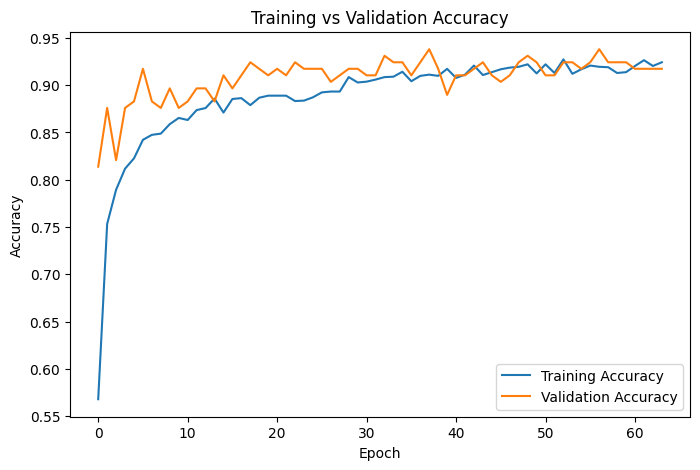

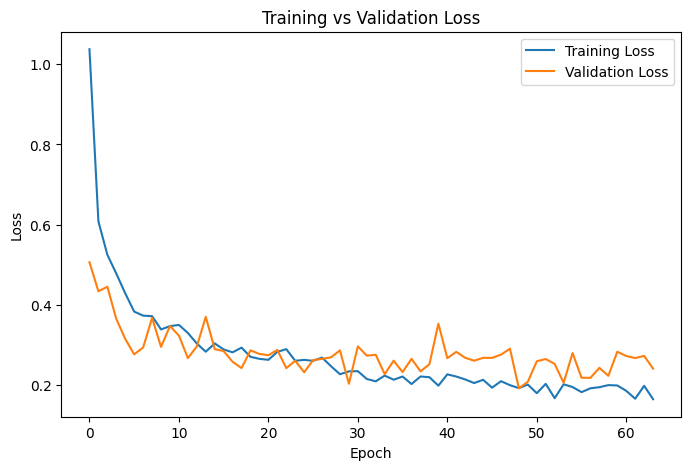

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [36]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

from sklearn.metrics import classification_report

target_names = [
    'glioma_tumor',
    'meningioma_tumor',
    'no_tumor',
    'pituitary_tumor'
]

print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )
)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy :", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.94      0.94      0.94       124
meningioma_tumor       0.90      0.83      0.87       124
        no_tumor       0.98      0.97      0.97        59
 pituitary_tumor       0.91      0.98      0.95       124

        accuracy                           0.93       431
       macro avg       0.93      0.93      0.93       431
    weighted avg       0.93      0.93      0.92       431

Test Accuracy : 0.925754060324826


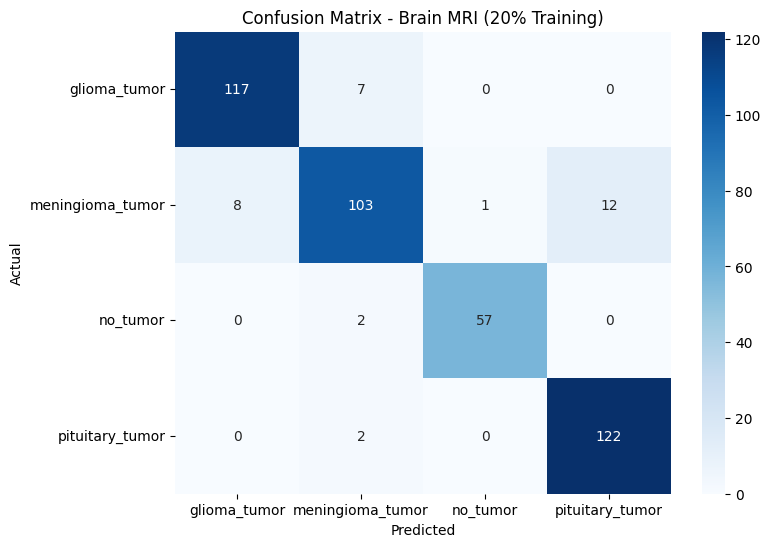

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Brain MRI (20% Training)")

plt.show()

In [38]:
# final training and validation

print("Final Validation Accuracy :", history.history['val_accuracy'][-1])
print("Final Training Loss :", history.history['loss'][-1])
print("Final Validation Loss :", history.history['val_loss'][-1])

# best validation accuracy

import numpy as np

best_epoch_acc = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = np.max(history.history['val_accuracy'])

print("Best Epoch :", best_epoch_acc)
print("Best Validation Accuracy :", best_val_acc)

# lowest validation loss

best_epoch_loss = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])

print("Best Epoch :", best_epoch_loss)
print("Lowest Validation Loss :", best_val_loss)

Final Validation Accuracy : 0.9172413945198059
Final Training Loss : 0.16482466459274292
Final Validation Loss : 0.24107474088668823
Best Epoch : 38
Best Validation Accuracy : 0.9379310607910156
Best Epoch : 49
Lowest Validation Loss : 0.19202305376529694
